# Semana 4 – Actividad 4: Métodos de Regularización en Redes Neuronales

**Institución:** Universidad de Cundinamarca  
**Programa:** Especialización en Inteligencia Artificial  
**Objetivo:** Analizar y mitigar el sobreentrenamiento (*overfitting*) aplicando L2, Dropout y Early Stopping sobre el dataset Diabetes, comparando el desempeño con y sin regularización.

## 0. Configuración del Entorno de Colab

> **Ejecutar primero esta celda.** Instala versiones compatibles de las librerías para evitar conflictos de importación en el entorno de Google Colab. El kernel se reiniciará automáticamente; después ejecuta las celdas restantes de arriba hacia abajo.

In [3]:
# Fija versiones compatibles con el entorno de Colab (Python 3.12)
# scikit-learn>=1.4 y pandas>=2.0 resuelven el ImportError de set_module
import subprocess, sys

packages = [
    "pandas>=2.0",
    "scikit-learn>=1.4",
    "tensorflow>=2.15",
    "matplotlib>=3.7",
    "numpy>=1.24",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ Librerías instaladas. Si el kernel se reinició, continúa desde la celda 1.")

✅ Librerías instaladas. Si el kernel se reinició, continúa desde la celda 1.


## 1. Importación de Librerías y Configuración de Semillas

Se fijan semillas en NumPy y TensorFlow para garantizar **reproducibilidad**: mismas semillas → mismos pesos y métricas en cada ejecución.

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Semillas fijas: cualquier persona que ejecute este notebook obtendrá los mismos resultados
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy:      {np.__version__}")

TensorFlow: 2.20.0
NumPy:      2.0.2


## 2. Carga y Preprocesamiento del Dataset

Se usa el dataset **Pima Indians Diabetes** (768 muestras, 8 características clínicas, etiqueta binaria).

| Paso | Técnica | Razón |
|---|---|---|
| Imputación | `SimpleImputer(strategy='mean')` | Reemplaza NaN con la media; común en datos médicos |
| Codificación | `LabelEncoder` | Convierte *tested_positive/negative* → 0/1 |
| División | `train_test_split(stratify=y)` | Mantiene la proporción de clases en ambos conjuntos |
| Escalamiento | `StandardScaler` | Las redes neuronales convergen mejor con datos en escala similar |

> **Importante:** el scaler se ajusta (`fit`) **solo** sobre el conjunto de entrenamiento y se aplica (`transform`) a ambos. Ajustarlo sobre el test introduciría *data leakage*.

In [5]:
print("Cargando dataset Pima Indians Diabetes desde OpenML...")
# fetch_openml descarga el dataset; version=1 fija la versión exacta para reproducibilidad
data = fetch_openml(name='diabetes', version=1, as_frame=True)
X = data.data   # DataFrame con 8 características clínicas
y = data.target # Serie con etiquetas: 'tested_positive' / 'tested_negative'

# Imputación: reemplaza valores nulos con la media de cada columna
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Codificación: convierte etiquetas de texto a enteros (0 / 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # tested_negative→0, tested_positive→1

# División 80/20 con estratificación para preservar la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalamiento: fit solo en train, transform en ambos (evita data leakage)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # Aprende μ y σ del conjunto de entrenamiento
X_test_s  = scaler.transform(X_test)       # Aplica el mismo μ y σ al conjunto de prueba

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape}")
print(f"Clases: {list(le.classes_)} → {list(range(len(le.classes_)))}")

Cargando dataset Pima Indians Diabetes desde OpenML...
Train: (614, 8) | Test: (154, 8)
Clases: ['tested_negative', 'tested_positive'] → [0, 1]


## 3. Arquitectura del Modelo

La función `build_model` construye un modelo denso con **dos capas ocultas (128 → 64 neuronas, ReLU)**. Es suficientemente complejo para mostrar overfitting en 150 épocas, lo que hace visible el efecto de cada técnica de regularización.

- **ReLU:** introduce no-linealidad sin el problema de *vanishing gradients* de tanh/sigmoide.  
- **Sigmoide en la salida:** produce una probabilidad ∈ (0,1) para clasificación binaria.  
- **Adam + binary_crossentropy:** combinación estándar y eficiente para este tipo de problema.

In [6]:
def build_model(name, regularization=None, dropout_rate=0.0):
    """
    Construye un modelo Sequential con regularización opcional.

    Parámetros
    ----------
    name           : str   – nombre del modelo (útil para identificarlo en logs)
    regularization : str   – 'l2' activa penalización L2 en capas Dense; None = sin regularización
    dropout_rate   : float – fracción de neuronas a desactivar por batch (0.0 = sin Dropout)
    """
    model = keras.Sequential(name=name)

    # Input: define la forma del tensor de entrada (nº de características)
    model.add(layers.Input(shape=(X_train_s.shape[1],)))

    # ── Capa oculta 1: 128 neuronas ───────────────────────────────────────────
    if regularization == 'l2':
        # kernel_regularizer añade λ·Σwᵢ² a la función de pérdida en esta capa
        # λ=0.01 penaliza pesos grandes → el modelo aprende representaciones más simples
        model.add(layers.Dense(128, activation="relu",
                               kernel_regularizer=regularizers.l2(0.01)))
    else:
        model.add(layers.Dense(128, activation="relu"))

    if dropout_rate > 0:
        # Dropout: desactiva aleatoriamente el dropout_rate% de neuronas por batch
        # Solo activo durante entrenamiento; en inferencia escala las salidas
        model.add(layers.Dropout(dropout_rate))

    # ── Capa oculta 2: 64 neuronas ────────────────────────────────────────────
    if regularization == 'l2':
        model.add(layers.Dense(64, activation="relu",
                               kernel_regularizer=regularizers.l2(0.01)))
    else:
        model.add(layers.Dense(64, activation="relu"))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida: sigmoide produce P(clase=1) ∈ (0,1)
    model.add(layers.Dense(1, activation="sigmoid"))

    # Compilación del modelo
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3), # Adaptative Moment Estimation
        loss="binary_crossentropy",  # Función de pérdida para clasificación binaria
        metrics=["accuracy"]         # Métrica reportada durante entrenamiento
    )
    return model

# Hiperparámetros compartidos por todos los modelos (experimento controlado)
EPOCHS           = 150   # Épocas máximas; Early Stopping puede interrumpir antes
BATCH_SIZE       = 32    # Muestras por actualización de gradiente
VALIDATION_SPLIT = 0.2   # 20% del train se reserva como validación interna

histories = {}  # Almacena el objeto History de cada modelo para graficar

## 4. Entrenamiento de los Cuatro Modelos

Se entrenan en secuencia con los mismos hiperparámetros para que las diferencias observadas sean **atribuibles exclusivamente a la técnica de regularización**, no a variaciones en el entrenamiento.

In [7]:
# ── Modelo 1: Baseline (sin regularización) ───────────────────────────────
# Sirve como referencia para medir cuánto overfitting produce la red sin intervención
print("Entrenando Modelo Base...")
model_base = build_model("Baseline")
histories['Base'] = model_base.fit(
    X_train_s, y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    verbose=0  # Suprime la salida por época para mantener el notebook limpio
)

# ── Modelo 2: Regularización L2 ────────────────────────────────────────────
# Penaliza pesos grandes → la red prefiere soluciones más simples y generalizables
print("Entrenando Modelo con L2...")
model_l2 = build_model("L2", regularization='l2')
histories['L2'] = model_l2.fit(
    X_train_s, y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    verbose=0
)

# ── Modelo 3: Dropout 40 % ─────────────────────────────────────────────────
# Desactiva el 40% de neuronas aleatoriamente por batch → ensamble implícito de subredes
print("Entrenando Modelo con Dropout...")
model_dropout = build_model("Dropout", dropout_rate=0.4)
histories['Dropout'] = model_dropout.fit(
    X_train_s, y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    verbose=0
)

# ── Modelo 4: Early Stopping ───────────────────────────────────────────────
print("Entrenando Modelo con Early Stopping...")
model_es = build_model("Early_Stopping")
early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss',       # Observa la pérdida sobre el conjunto de validación
    patience=15,              # Para si val_loss no mejora en 15 épocas consecutivas
    restore_best_weights=True # Recupera los pesos del epoch con menor val_loss
)
histories['Early_Stopping'] = model_es.fit(
    X_train_s, y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stopping_cb],
    verbose=0
)

# Reporta en qué época actuó Early Stopping (evidencia de trazabilidad)
ep = early_stopping_cb.stopped_epoch
print(f"\nResumen de entrenamiento:")
print(f"  Early Stopping se detuvo en la época: {ep if ep > 0 else EPOCHS} / {EPOCHS}")
print("  ✅ Todos los modelos entrenados.")

Entrenando Modelo Base...
Entrenando Modelo con L2...
Entrenando Modelo con Dropout...
Entrenando Modelo con Early Stopping...

Resumen de entrenamiento:
  Early Stopping se detuvo en la época: 28 / 150
  ✅ Todos los modelos entrenados.


## 5. Visualización Comparativa

Las gráficas muestran `val_loss` y `val_accuracy` por época para los cuatro modelos.

**Cómo interpretar:**
- **Baseline:** se espera que `val_loss` suba después de cierto punto → señal clásica de overfitting.
- **Modelos regularizados:** curvas más estables y aplanadas, menor varianza entre épocas.
- **Early Stopping:** la curva termina antes de las 150 épocas.

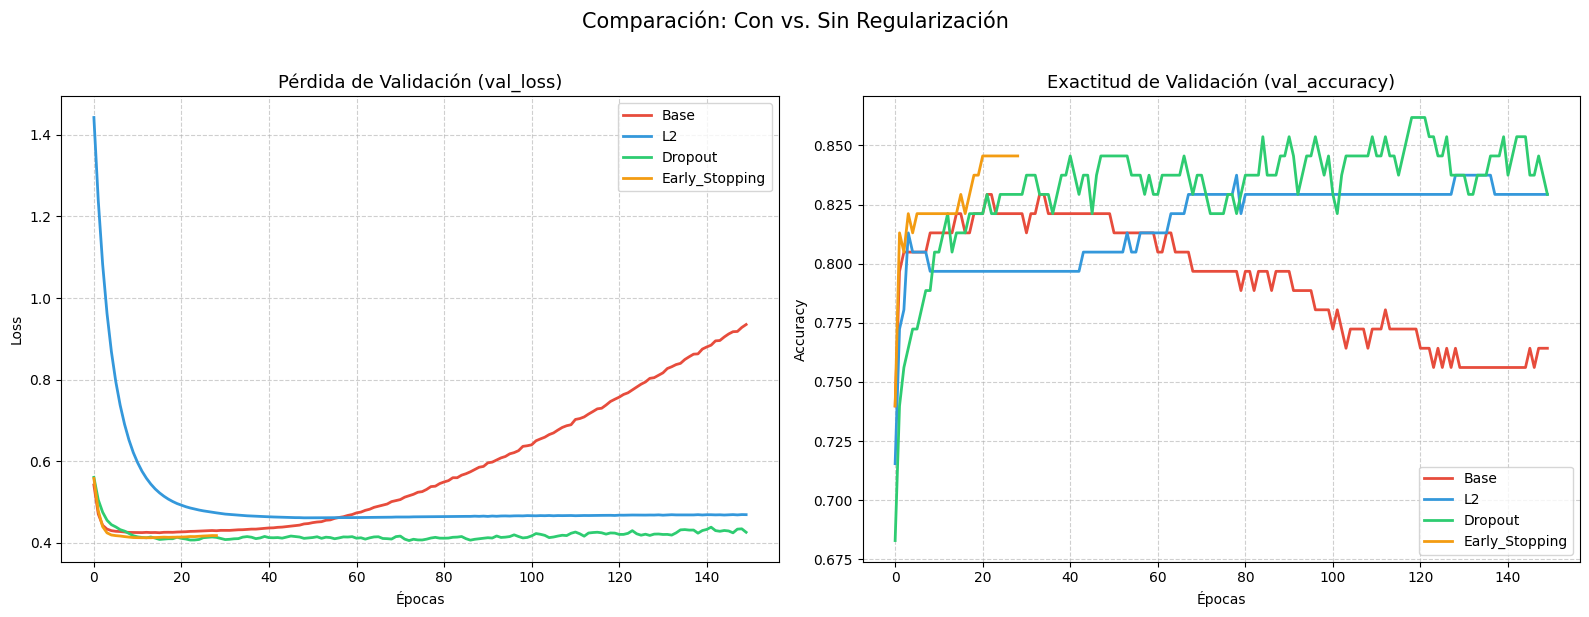

In [8]:
def plot_comparisons(histories):
    """
    Genera dos subgráficas comparando val_loss y val_accuracy de todos los modelos.
    Solo se grafican métricas de validación (no de entrenamiento) para enfocarse
    en la capacidad de generalización de cada técnica.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Paleta de colores consistente para identificar cada modelo
    colors = {
        'Base':          '#e74c3c',  # Rojo: modelo de referencia
        'L2':            '#3498db',  # Azul: regularización L2
        'Dropout':       '#2ecc71',  # Verde: Dropout
        'Early_Stopping':'#f39c12'   # Naranja: Early Stopping
    }

    for name, history in histories.items():
        c = colors.get(name, 'gray')
        # val_loss: pérdida en validación → detecta overfitting cuando sube mientras train_loss baja
        axes[0].plot(history.history['val_loss'],
                     label=name, color=c, linewidth=2)
        # val_accuracy: exactitud en validación → mide capacidad de generalización real
        axes[1].plot(history.history['val_accuracy'],
                     label=name, color=c, linewidth=2)

    axes[0].set_title('Pérdida de Validación (val_loss)', fontsize=13)
    axes[0].set_xlabel('Épocas')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].set_title('Exactitud de Validación (val_accuracy)', fontsize=13)
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('Comparación: Con vs. Sin Regularización', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

plot_comparisons(histories)

## 6. Evaluación Final en el Conjunto de Prueba

Se mide el desempeño de cada modelo sobre el **test set** (datos nunca vistos durante el entrenamiento ni la validación interna). Esta es la métrica más honesta de la capacidad de generalización.

Modelo                  Test Loss  Test Accuracy
Base                       0.9603         0.7338
L2                         0.5458         0.7468
Dropout                    0.5391         0.7532
Early_Stopping             0.4941         0.7403


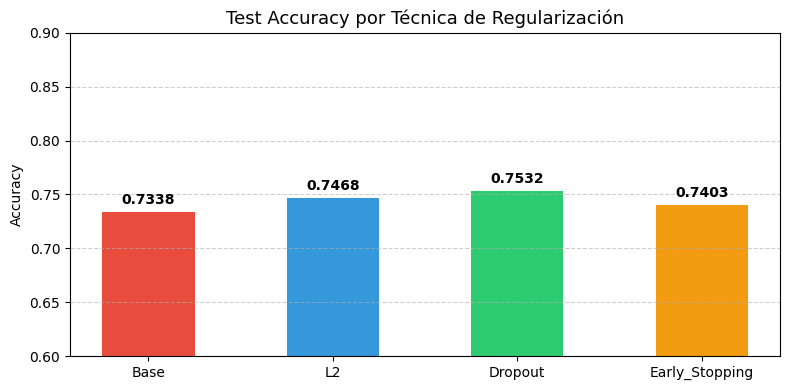

In [9]:
# ── Tabla de resultados en Test Set ───────────────────────────────────────
print("=" * 58)
print(f"{'Modelo':<20} {'Test Loss':>12} {'Test Accuracy':>14}")
print("=" * 58)

results = {}
model_map = {
    'Base': model_base,
    'L2': model_l2,
    'Dropout': model_dropout,
    'Early_Stopping': model_es
}

for name, model in model_map.items():
    # evaluate() devuelve [loss, accuracy] sobre el conjunto de prueba
    loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
    results[name] = {'loss': loss, 'acc': acc}
    print(f"{name:<20} {loss:>12.4f} {acc:>14.4f}")

print("=" * 58)

# ── Gráfica de barras: Test Accuracy por modelo ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
nombres = list(results.keys())
accs    = [results[n]['acc'] for n in nombres]
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

bars = ax.bar(nombres, accs, color=colores, width=0.5)

# Anota el valor exacto sobre cada barra para facilitar la comparación
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.6, 0.9)
ax.set_title('Test Accuracy por Técnica de Regularización', fontsize=13)
ax.set_ylabel('Accuracy')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 7. Análisis del Impacto de las Técnicas de Regularización

### ¿Por qué ocurre el overfitting?

Cuando un modelo entrena demasiadas épocas sobre datos limitados, comienza a memorizar el *ruido estadístico* del conjunto de entrenamiento. Esto se manifiesta como:
- `train_loss` sigue bajando mientras `val_loss` **sube** → alta varianza.
- El modelo funciona bien en entrenamiento pero falla en datos nuevos.

### Justificación de las técnicas seleccionadas

| Técnica | Mecanismo matemático | Por qué es adecuada aquí |
|---|---|---|
| **L2 (Weight Decay)** | Añade $\lambda \sum w_i^2$ a la pérdida. Los pesos grandes son penalizados. | Efectiva con variables clínicas continuas con ruido gaussiano. Suaviza las fronteras de decisión. |
| **Dropout (40 %)** | Desactiva aleatoriamente el 40 % de neuronas por batch. La red no puede depender de ninguna neurona individual. | Actúa como ensamble implícito de $2^n$ subredes. Especialmente útil en capas densas grandes (128, 64). |
| **Early Stopping** | Monitorea `val_loss` y restaura los pesos del mejor epoch cuando la métrica se estanca. | La técnica más directa: interrumpe el entrenamiento antes de que el modelo empiece a memorizar ruido. Complementa a cualquier otra técnica. |

### Conclusión

La regularización **no siempre maximiza el accuracy puntual**, pero **estabiliza la curva de validación** y reduce la brecha entre train y test. Un modelo regularizado con accuracy estable es más confiable en producción que uno sin regularizar con picos de accuracy en entrenamiento.

> **Recomendación práctica:** Combinar Early Stopping + Dropout o Early Stopping + L2 suele producir los mejores resultados de generalización sin aumentar la complejidad del modelo.